Data Cleaning
====

Illustrate + provide some basic stats on the data cleaning

In [1]:
import os

%load_ext autoreload
%autoreload 2

img_dir = "outputs/imgs/clean/"
if not os.path.exists(img_dir):
    os.makedirs(img_dir)

In [2]:
"""
Read the meal entries and provide some stats

"""
from analysis_utils import read

raw_entries = read.all_meal_info()

print(f"{len(raw_entries.p_id.unique())} unique participants; {len(raw_entries)} total entries")

/home/mh19137/seaco_smartwatch_paper/analysis_utils/clean.py:156: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Normal' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  copy.loc[start_time, col_name] = "Normal"
/home/mh19137/seaco_smartwatch_paper/analysis_utils/clean.py:227: UserWarning: Long catchup: not marking Meal at 2022-05-19 09:02:49 as catchup
  warnings.warn(


 Open ended catchup at 2022-02-11 20:02:05 ended by No response at 2022-02-12 08:02:11
 Open ended catchup at 2022-02-14 20:26:30 ended by No response at 2022-02-15 08:02:16
 Open ended catchup at 2022-04-19 08:01:14 ended by No catch-up at 2022-04-19 08:01:17
 Open ended catchup at 2022-06-27 15:53:14 ended by Catch-up start at 2022-06-27 15:54:06
 Open ended catchup at 2021-12-31 22:11:10 ended by No catch-up at 2022-01-01 08:01:15
 Open ended catchup at 2022-05-24 07:25:36 ended by Catch-up start at 2022-05-24 07:26:00
 Open ended catchup at 2022-03-21 08:01:57 ended by No catch-up at 2022-03-21 08:02:04
 Open ended catchup at 2022-03-07 18:33:30 ended by No catch-up at 2022-03-07 18:33:34
 Open ended catchup at 2022-03-07 18:37:08 ended by No catch-up at 2022-03-07 18:37:14
 Open ended catchup at 2022-03-07 19:29:23 ended by No response at 2022-03-08 08:02:56
 Open ended catchup at 2022-03-08 08:30:40 ended by No catch-up at 2022-03-08 08:31:08
 Open ended catchup at 2022-03-08 09:

100%|██████████| 83/83 [00:00<00:00, 688.09it/s]


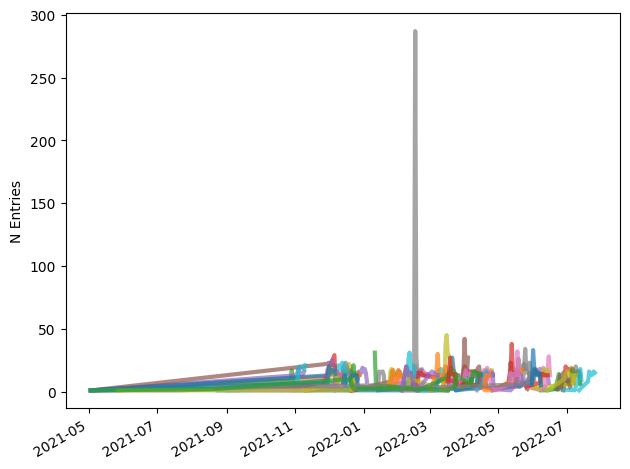

In [3]:
"""
Plot the number of entries per participant and the date

"""

import matplotlib.pyplot as plt

from tqdm import tqdm

def plot(df, path):
    fig, axis = plt.subplots()

    # Plot the number of entries per participant per day
    for _, group in tqdm(df.groupby("p_id")):
        # Find the number of entries per day
        dates = []
        n = []

        # Group by date
        group["Date"] = group.index.date
        for _, group2 in group.groupby("Date"):
            dates.append(group2.index[0].date())
            n.append(len(group2))

        axis.plot(dates, n, linewidth=3, alpha=0.7, linestyle="-")

    fig.autofmt_xdate()

    axis.set_ylabel("N Entries")
    fig.tight_layout()
    fig.savefig(path)

plot(raw_entries, f"{img_dir}/raw_entries_per_day.png")

100%|██████████| 83/83 [00:00<00:00, 956.40it/s]


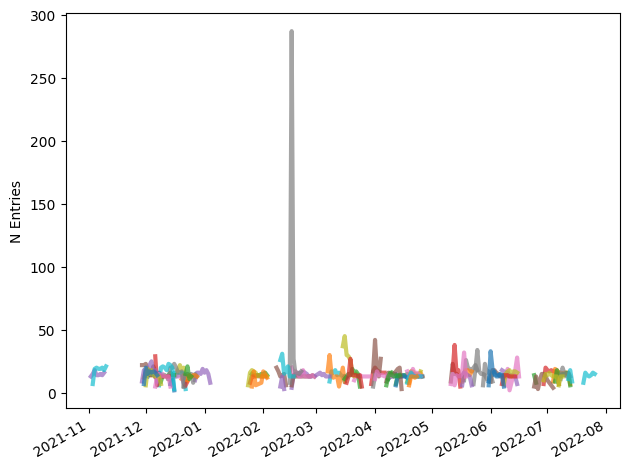

In [4]:
"""
Remove entries before the first day

"""
cleaned = raw_entries.copy()
cleaned = cleaned[cleaned["delta"].dt.days >= 0]

plot(cleaned, f"{img_dir}/removed_early_entries_per_day.png")


100%|██████████| 83/83 [00:00<00:00, 888.83it/s]


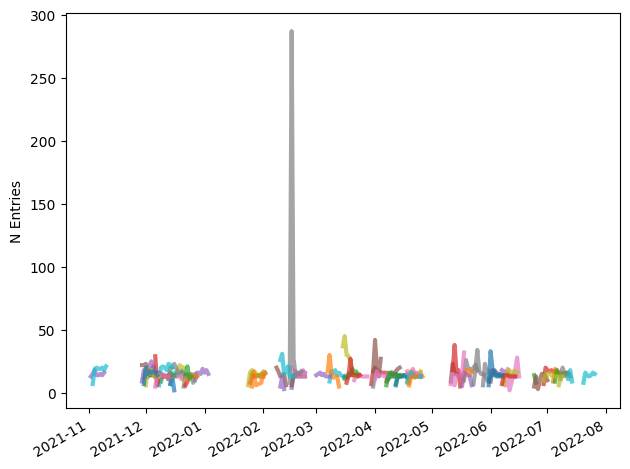

In [5]:
"""
Remove entries after day 7

"""
cleaned = cleaned[cleaned["delta"].dt.days <= 7]

plot(cleaned, f"{img_dir}/removed_late_early_entries_per_day.png")

100%|██████████| 83/83 [00:00<00:00, 1020.43it/s]


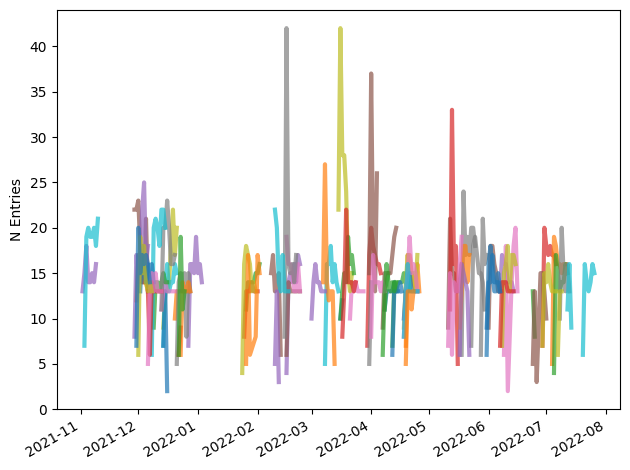

In [6]:
"""
Remove duplicates

"""
from analysis_utils import clean

cleaned = cleaned.sort_index()
cleaned = cleaned[~clean.duplicates(cleaned)]

plot(cleaned, f"{img_dir}/removed_duplicates_per_day.png")

100%|██████████| 83/83 [00:00<00:00, 878.07it/s]


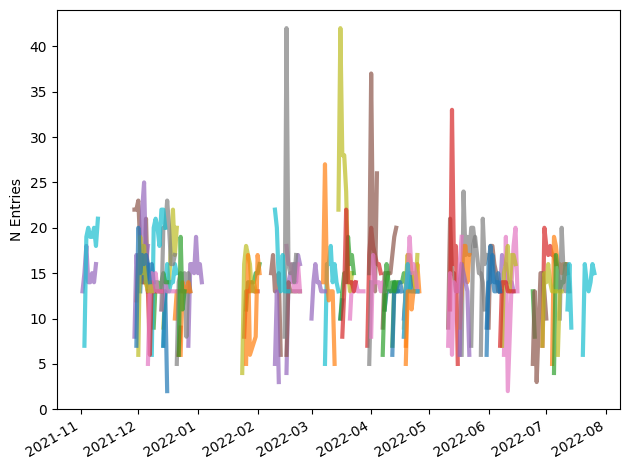

In [7]:
"""
Compare to the library function for cleaning

"""
cleaned2 = clean.cleaned_smartwatch(keep_catchups=True, keep_day0=True)

plot(cleaned2, f"{img_dir}/removed_duplicates_per_day_lib.png")

There is actually a small difference between these plots, but hopefully it doesn't matter...